# Phase 1: Exploratory Data Analysis (EDA)

This notebook covers the requirements for Phase 1. It visualizes the cleaned training data to explain how different features affect Heart Disease and each other.

In [19]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for nice visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [20]:
# Load the Cleaned Data
df = pd.read_csv('../data/Cleaned_Train_Data.csv')
df.head()

,Age,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,...,Gender_Male,work_type_Govt_job,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,Heart Disease
0,70,4,130,322,0,2,109,0,2.4,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,67,3,115,370,0,2,160,0,1.6,2,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0
2,57,2,124,261,0,0,141,0,0.3,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
3,64,4,128,263,0,0,105,1,0.2,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,74,2,120,269,0,2,121,1,0.2,1,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0


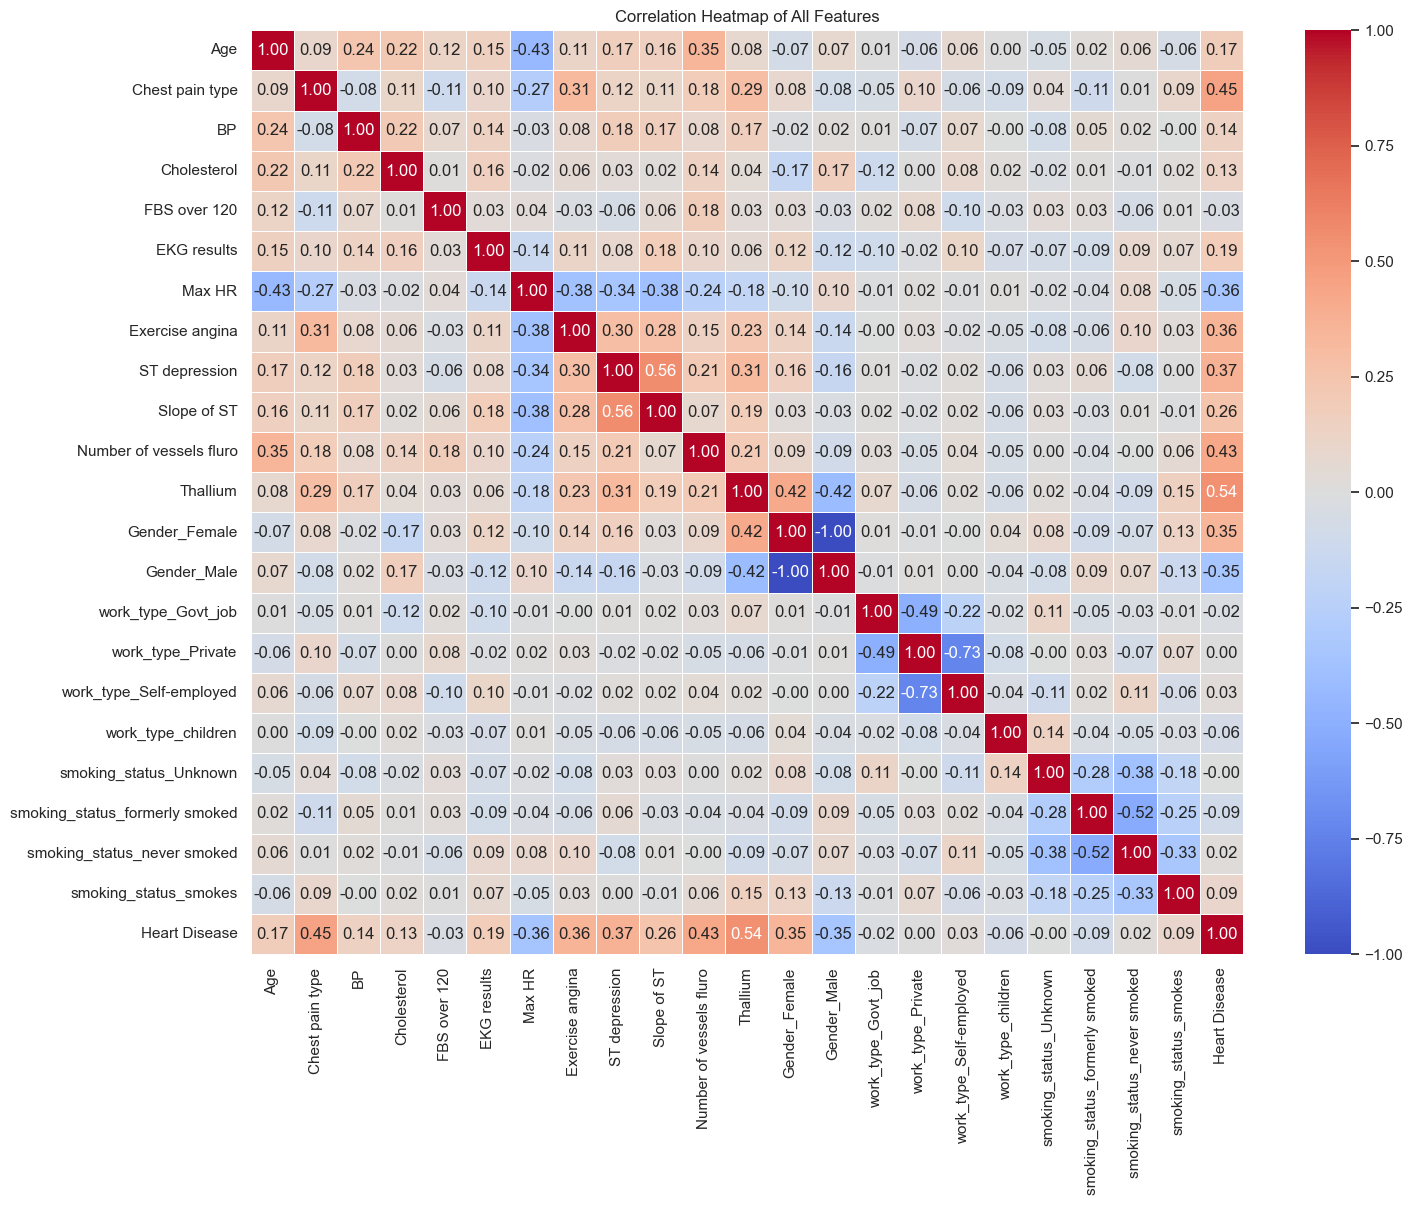

In [21]:
# 1. Correlation Heatmap
plt.figure(figsize=(16, 12))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of All Features")
plt.show()

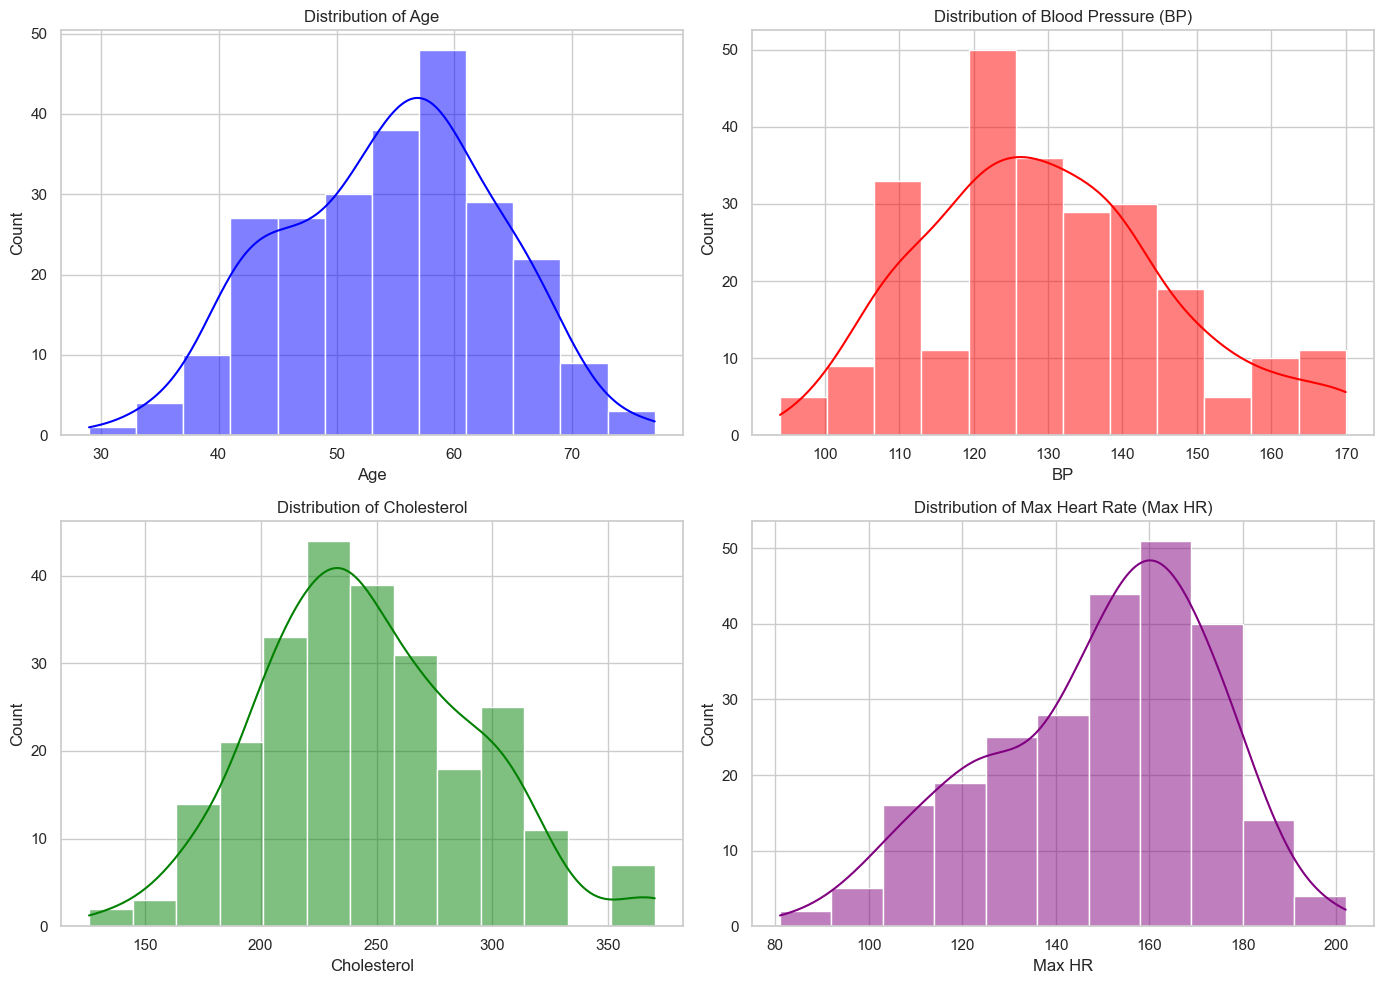

In [22]:
# 2. Distribution Plot for Continuous Variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Age'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Distribution of Age')

sns.histplot(df['BP'], kde=True, ax=axes[0, 1], color='red')
axes[0, 1].set_title('Distribution of Blood Pressure (BP)')

sns.histplot(df['Cholesterol'], kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribution of Cholesterol')

sns.histplot(df['Max HR'], kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Distribution of Max Heart Rate (Max HR)')

plt.tight_layout()
plt.show()

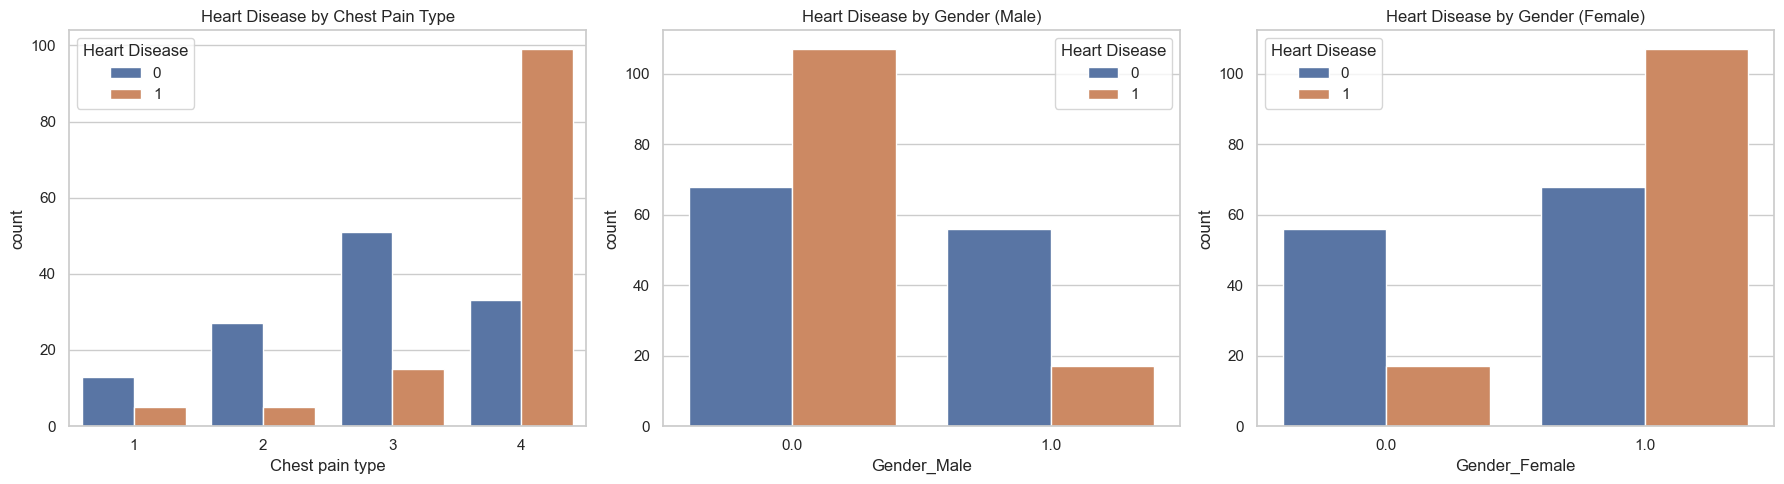

In [23]:
# 3. Bar Charts: Categorical vs Heart Disease
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Chest pain type', hue='Heart Disease', ax=axes[0])
axes[0].set_title('Heart Disease by Chest Pain Type')

sns.countplot(data=df, x='Gender_Male', hue='Heart Disease', ax=axes[1])
axes[1].set_title('Heart Disease by Gender (Male)')

sns.countplot(data=df, x='Gender_Female', hue='Heart Disease', ax=axes[2])
axes[2].set_title('Heart Disease by Gender (Female)')

plt.tight_layout()
plt.show()

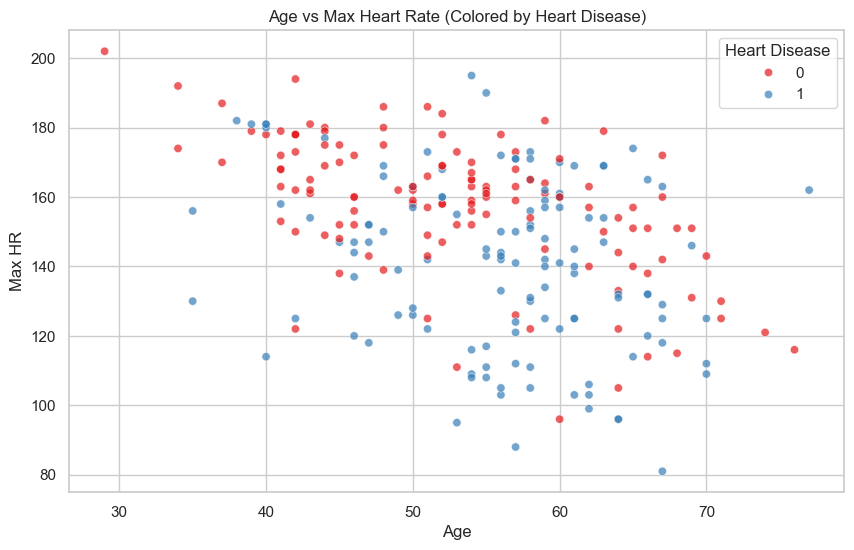

In [24]:
# 4. Scatter Plot and Interaction (Age vs Max HR Colored by Heart Disease)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Max HR', hue='Heart Disease', alpha=0.7, palette='Set1')
plt.title('Age vs Max Heart Rate (Colored by Heart Disease)')
plt.show()

## 5. Advanced Analysis: Outlier Verification & Deep Insights
Now we will generate Boxplots to verify if the IQR capping removed the extreme outliers, followed by proportional charts, an interaction matrix, and a Tree-based Feature Importance ranking.

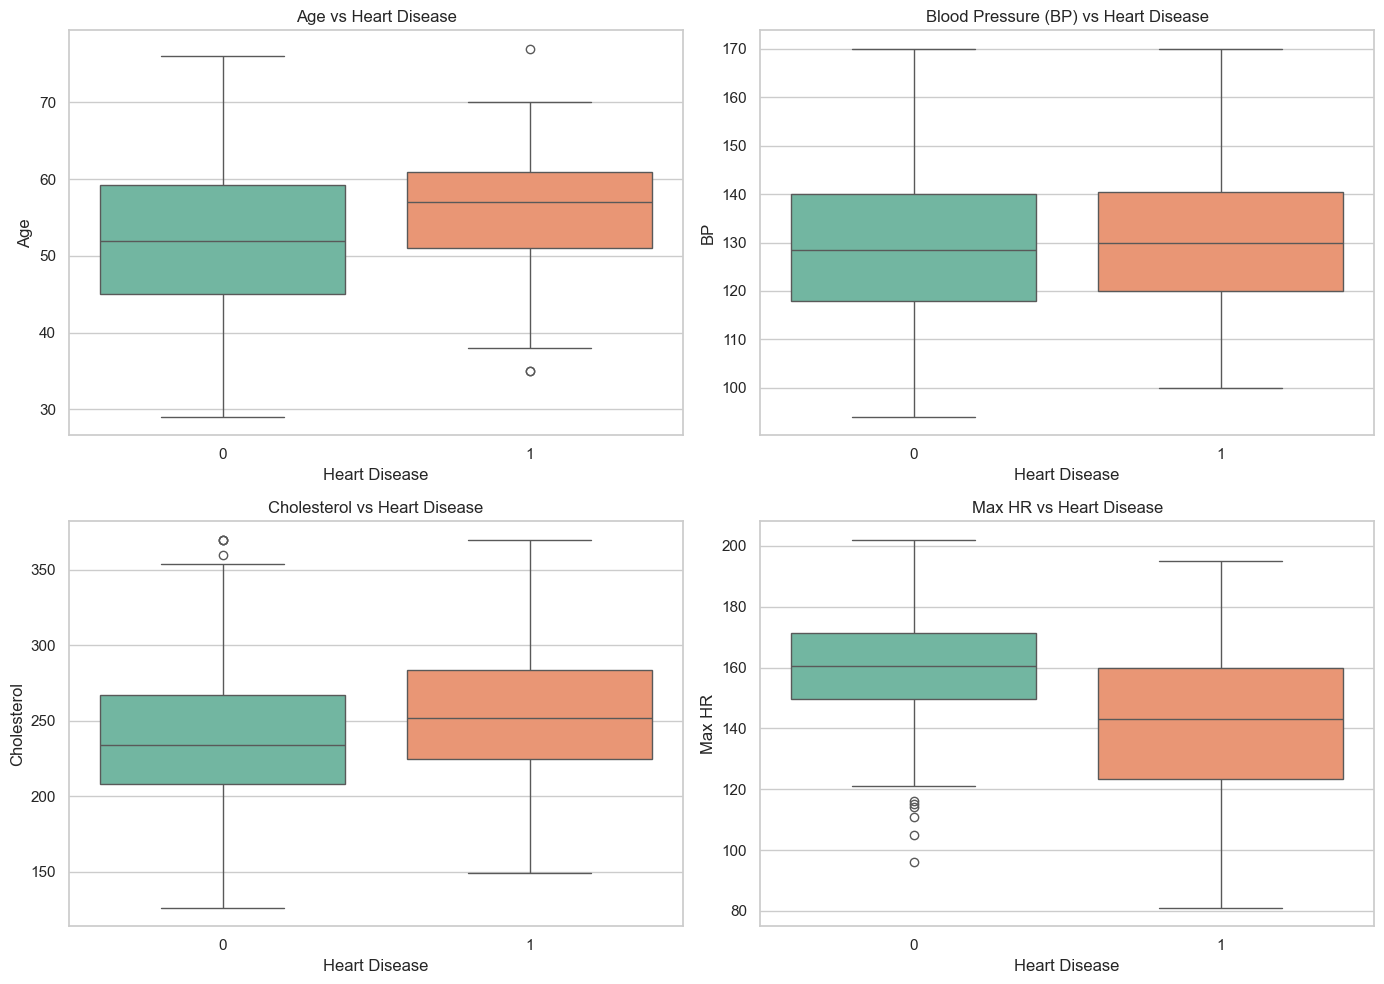

In [25]:
# 5.1 Boxplots for Outlier Verification
# This will show us if the IQR method successfully contained BP and Cholesterol
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Heart Disease', y='Age', hue='Heart Disease', ax=axes[0, 0], palette='Set2', legend=False)
axes[0, 0].set_title('Age vs Heart Disease')

sns.boxplot(data=df, x='Heart Disease', y='BP', hue='Heart Disease', ax=axes[0, 1], palette='Set2', legend=False)
axes[0, 1].set_title('Blood Pressure (BP) vs Heart Disease')

sns.boxplot(data=df, x='Heart Disease', y='Cholesterol', hue='Heart Disease', ax=axes[1, 0], palette='Set2', legend=False)
axes[1, 0].set_title('Cholesterol vs Heart Disease')

sns.boxplot(data=df, x='Heart Disease', y='Max HR', hue='Heart Disease', ax=axes[1, 1], palette='Set2', legend=False)
axes[1, 1].set_title('Max HR vs Heart Disease')

plt.tight_layout()
plt.show()

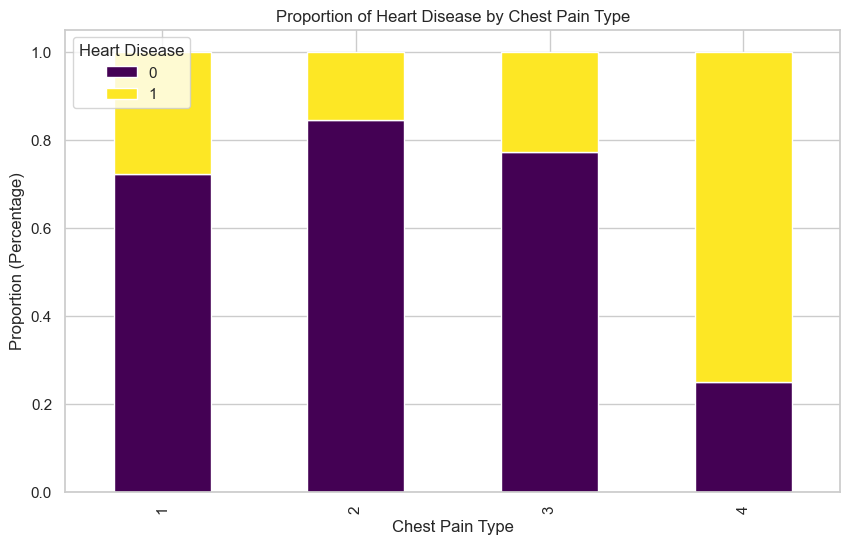

In [26]:
# 5.2 Proportional Stacked Bar Chart for Chest Pain Type
# Instead of raw counts, this shows the EXACT probability of having heart disease based on pain type
crosstab = pd.crosstab(df['Chest pain type'], df['Heart Disease'], normalize='index')
crosstab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title('Proportion of Heart Disease by Chest Pain Type')
plt.ylabel('Proportion (Percentage)')
plt.xlabel('Chest Pain Type')
plt.legend(title='Heart Disease', loc='upper left')
plt.show()

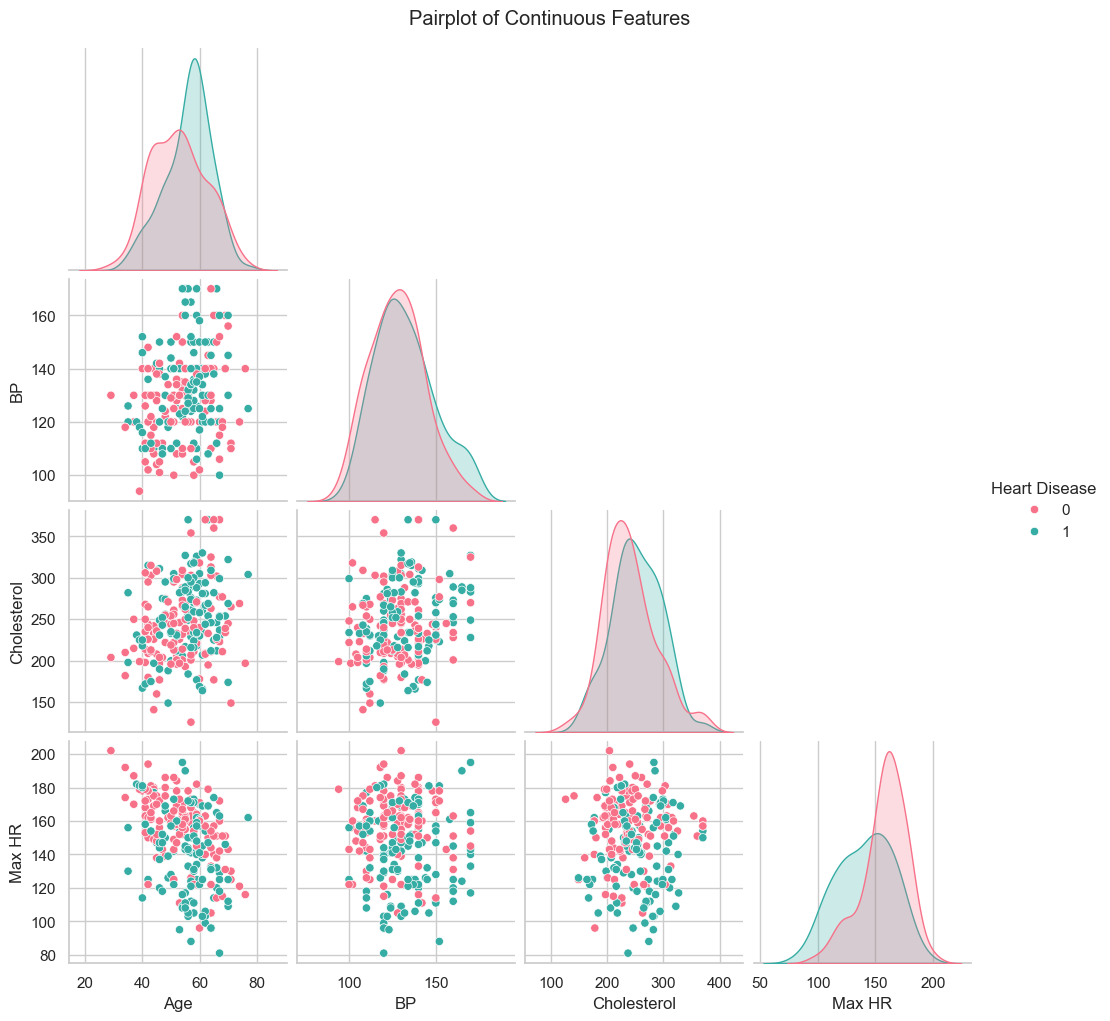

In [27]:
# 5.3 Pairplot (Interaction Matrix)
# This plots every continuous feature against every other continuous feature to find hidden clusters
features_to_plot = ['Age', 'BP', 'Cholesterol', 'Max HR', 'Heart Disease']
sns.pairplot(df[features_to_plot], hue='Heart Disease', palette='husl', corner=True)
plt.suptitle("Pairplot of Continuous Features", y=1.02)
plt.show()

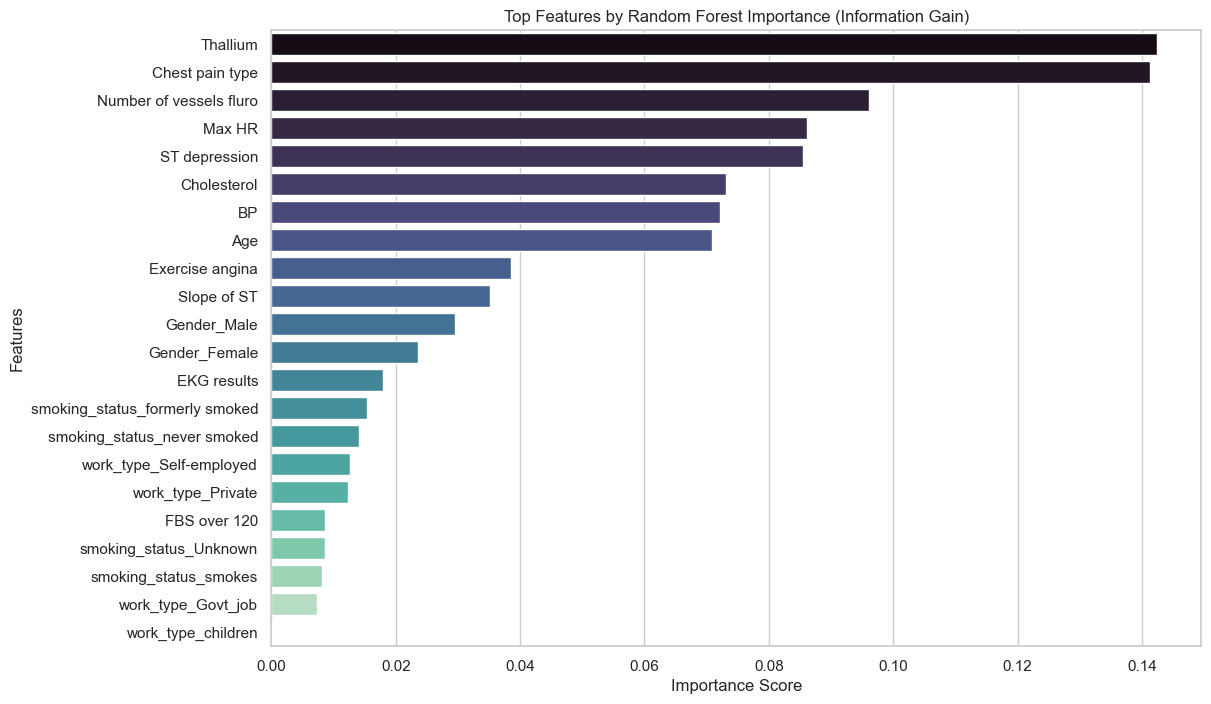

In [28]:
# 5.4 Feature Importance using a Tree-Based Model (Random Forest)
# This mathematically proves which features give the most "Information Gain"
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='mako', legend=False)
plt.title('Top Features by Random Forest Importance (Information Gain)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()